# Hybrid Retrieval for Healthcare Conversational Question Answering

**Course:** Conversational AI — Semester 3 Assignment PS1
**Dataset:** MedQuAD (NIH Medical Question Answering Dataset)
**Methods:** BM25 Sparse · Sentence Transformers Dense · Reciprocal Rank Fusion Hybrid

---

## Assignment Overview

This notebook implements a complete end-to-end **Healthcare Hybrid Retrieval QA System** covering all 6 assignment tasks:

| Module | Task | Description | Marks |
|--------|------|-------------|-------|
| 1 | Task 1 | Healthcare Data Cleaning and Preparation | 1.5 |
| 1 | Task 2 | Sparse Search System using BM25 | 1.5 |
| 2 | Task 3 | Semantic Retrieval using Sentence Transformers | 2.0 |
| 2 | Task 4 | Hybrid Retrieval using RRF | 1.5 |
| 3 | Task 5 | Conversational QA Pipeline | 2.0 |
| 3 | Task 6 | Retrieval Evaluation and Performance Analysis | 1.5 |

**Dataset:** MedQuAD — 47,457 medical QA pairs from 12 NIH websites, covering diseases, symptoms, medications, diagnostics, treatments, and preventive care.

> ⚠️ **Medical Disclaimer:** This system is for educational purposes only and is not a substitute for professional medical advice, diagnosis, or treatment.

---

## Reproducibility Notes

**Before running this notebook:**

1. **Dataset** — `medquad.csv` must be in the **same folder as this notebook** (or in `./data/raw/`). The notebook does **not** download or fabricate the dataset. If it is missing, Cell 3 raises a clear error explaining how to fix it. Obtain MedQuAD from <https://github.com/abachaa/MedQuAD> and export the question/answer/source/focus_area fields to `medquad.csv`.
2. **Internet (first run only)** — Cell 7 downloads the `all-MiniLM-L6-v2` Sentence-Transformers model (~90 MB) from Hugging Face on first execution. After the first run the model is cached locally and document embeddings are saved to `data/processed/embeddings.npy`, so subsequent runs need no internet.
3. **Run order** — Execute cells top to bottom (Cell 1 → Cell 16). Cell 2 installs the required packages.

In [1]:
# Install required packages
import subprocess, sys
for pkg in ['rank-bm25', 'sentence-transformers', 'beautifulsoup4', 'tqdm']:
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q',
                        '--break-system-packages'], capture_output=True, text=True)
    print(f"  {pkg}: {'ok' if r.returncode == 0 else 'skipped'}")

import os, re, time, warnings, html as html_lib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from bs4 import BeautifulSoup
from tqdm import tqdm
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
np.random.seed(42)

NOTEBOOK_DIR = os.path.abspath('')
BASE_DIR     = os.path.join(NOTEBOOK_DIR, '..')
RAW_PATH     = os.path.join(BASE_DIR, 'data', 'raw',       'medquad.csv')
PROC_PATH    = os.path.join(BASE_DIR, 'data', 'processed', 'medquad_processed.csv')
EMB_PATH     = os.path.join(BASE_DIR, 'data', 'processed', 'embeddings.npy')
OUT_DIR      = os.path.join(BASE_DIR, 'outputs')
os.makedirs(os.path.dirname(PROC_PATH), exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)
print('All imports successful.')

  rank-bm25: ok


  sentence-transformers: ok


  beautifulsoup4: ok


  tqdm: ok


All imports successful.


## 3. Load Dataset

> **Reproducibility:** To rerun this notebook from scratch, place `medquad.csv` in the same directory as the notebook. Internet access is required the first time the Sentence Transformers model is downloaded.

The loader below sets `DATA_PATH = "medquad.csv"`, auto-detects the question/answer/source/focus_area columns, and raises a clear error if the file is missing.

In [2]:
# ── Configuration: change DATA_PATH if your file has a different name ──
DATA_PATH = "medquad.csv"

def _find_data_file(filename):
    candidates = [filename,
                  os.path.join(NOTEBOOK_DIR, filename),
                  os.path.join(BASE_DIR, filename),
                  os.path.join(BASE_DIR, 'data', filename),
                  os.path.join(BASE_DIR, 'data', 'raw', filename)]
    for p in candidates:
        if os.path.exists(p):
            return os.path.abspath(p)
    tried = '\n'.join(f'    - {p}' for p in candidates)
    raise FileNotFoundError(
        f"\nDataset '{filename}' not found.\n"
        f"Place '{filename}' in the SAME FOLDER as this notebook "
        f"(or in ./data/raw/) and re-run this cell.\n"
        f"MedQuAD source: https://github.com/abachaa/MedQuAD\n"
        f"Searched these locations:\n{tried}"
    )

resolved_path = _find_data_file(DATA_PATH)
print(f"Found: {resolved_path}")

df_raw = pd.read_csv(resolved_path)
df_raw.columns = [c.strip().lower().replace(' ', '_') for c in df_raw.columns]
print(f"Raw shape: {df_raw.shape}  |  Columns: {list(df_raw.columns)}")

# Auto-detect question/answer/source/focus_area columns
def _detect(cols, aliases):
    for a in aliases:
        if a in cols: return a
    for a in aliases:
        for c in cols:
            if a in c: return c
    return None

q_col = _detect(df_raw.columns, ['question','query','q'])
a_col = _detect(df_raw.columns, ['answer','response','a','text','passage'])
s_col = _detect(df_raw.columns, ['source','src','dataset'])
f_col = _detect(df_raw.columns, ['focus_area','focus','topic','category'])
print(f"Detected: question='{q_col}'  answer='{a_col}'  source='{s_col}'  focus='{f_col}'")

df = pd.DataFrame({
    'question'  : df_raw[q_col].astype(str).str.strip(),
    'answer'    : df_raw[a_col].astype(str).str.strip(),
    'source'    : df_raw[s_col].astype(str).str.strip() if s_col else 'unknown',
    'focus_area': df_raw[f_col].astype(str).str.strip() if f_col else '',
})
before = len(df)
df = df[~df['question'].isin(['','nan','None'])]
df = df[~df['answer'].isin(['','nan','None'])]
df = df[df['question'].str.len() > 5]
df = df[df['answer'].str.len() > 10]
df = df.drop_duplicates(subset=['question','answer']).reset_index(drop=True)
df['doc_id']       = df.index
df['document_text'] = df['question'] + ' ' + df['answer']
print(f"Records: {before:,} raw → {len(df):,} after cleaning ({before-len(df):,} removed)")
print(f"Columns: {list(df.columns)}")
df.head(3)

Found: /Users/rilakkiya/Library/CloudStorage/OneDrive-athenahealth/Desktop/myPC/Ilakkiya_personal/PG/Sem 3/Assignments/CAI/healthcare_hybrid_retrieval/data/raw/medquad.csv
Raw shape: (16407, 4)  |  Columns: ['question', 'answer', 'source', 'focus_area']
Detected: question='question'  answer='answer'  source='source'  focus='focus_area'


Records: 16,407 raw → 16,358 after cleaning (49 removed)
Columns: ['question', 'answer', 'source', 'focus_area', 'doc_id', 'document_text']


,question,answer,source,focus_area,doc_id,document_text
0,What is (are) keratoderma with woolly hair ?,Keratoderma with woolly hair is a group of rel...,3_GHR_QA,keratoderma with woolly hair,0,What is (are) keratoderma with woolly hair ? K...
1,How many people are affected by keratoderma wi...,Keratoderma with woolly hair is rare; its prev...,3_GHR_QA,keratoderma with woolly hair,1,How many people are affected by keratoderma wi...
2,What are the genetic changes related to kerato...,"Mutations in the JUP, DSP, DSC2, and KANK2 gen...",3_GHR_QA,keratoderma with woolly hair,2,What are the genetic changes related to kerato...


=== BEFORE / AFTER CLEANING EXAMPLES ===
  BEFORE: <p>Symptoms&nbsp;of <b>Type 2 Diabetes</b>:
Blood sugar &gt; 126 mg/dL.
  AFTER : symptoms of type 2 diabetes : blood sugar 126 mg/dl.

  BEFORE: Treatment: beta-blocker (atenolol) 25-50mg/day. Monitor ALT/AST. pH < 7.3.
  AFTER : treatment: beta-blocker (atenolol) 25-50mg/day. monitor alt/ast. ph 7.3.

Total QA pairs       : 16,358
Unique NIH sources   : 9
Avg question tokens  : 7.2


Avg answer tokens    : 200.4
Avg doc tokens       : 207.6  |  median: 144

Records per NIH source:
source
3_GHR_QA                    5430
2_GARD_QA                   5389
5_NIDDK_QA                  1144
6_NINDS_QA                  1088
4_MPlus_Health_Topics_QA     981
7_SeniorHealth_QA            769
1_CancerGov_QA               729
8_NHLBI_QA_XML               559
9_CDC_QA                     269


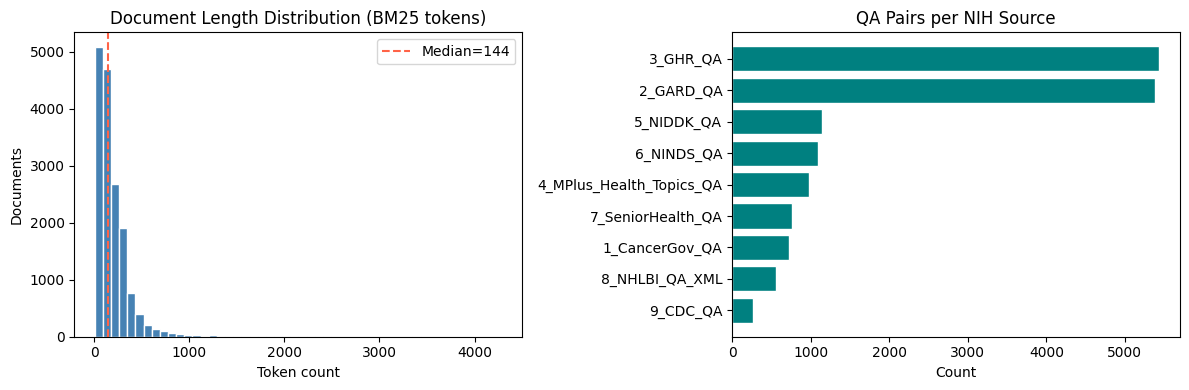

In [3]:
# ── Cleaning functions ────────────────────────────────────────────────────
def clean_text(text, lowercase=True):
    """Remove HTML, decode entities, normalize whitespace. Preserve medical tokens."""
    if not isinstance(text, str): return ''
    text = text.strip()
    if text in ('', 'nan', 'None'): return ''
    text = html_lib.unescape(text)                         # &amp; → &
    text = BeautifulSoup(text, 'html.parser').get_text(' ')# strip HTML tags
    text = re.sub(r"[^\w\s\-\.\,\%\/\(\)\:\']", ' ', text)  # keep medical chars
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower() if lowercase else text

def tokenize_for_bm25(text):
    """Whitespace tokenizer — BM25 handles IDF so no stopword removal needed."""
    return text.lower().split()

# ── Apply cleaning ─────────────────────────────────────────────────────────
df['clean_question']      = df['question'].apply(clean_text)
df['clean_answer']        = df['answer'].apply(clean_text)
df['clean_document_text'] = df['clean_question'] + ' ' + df['clean_answer']
df['bm25_tokens']         = df['clean_document_text'].apply(tokenize_for_bm25)
df.to_csv(PROC_PATH, index=False)

# Before/after examples
print("=== BEFORE / AFTER CLEANING EXAMPLES ===")
EXAMPLES = [
    "<p>Symptoms&nbsp;of <b>Type 2 Diabetes</b>:\nBlood sugar &gt; 126 mg/dL.",
    "Treatment: beta-blocker (atenolol) 25-50mg/day. Monitor ALT/AST. pH < 7.3.",
]
for raw in EXAMPLES:
    print(f"  BEFORE: {raw[:80]}")
    print(f"  AFTER : {clean_text(raw)[:80]}")
    print()

# Dataset stats
doc_len = df['bm25_tokens'].str.len()
print(f"Total QA pairs       : {len(df):,}")
print(f"Unique NIH sources   : {df['source'].nunique()}")
print(f"Avg question tokens  : {df['clean_question'].str.split().str.len().mean():.1f}")
print(f"Avg answer tokens    : {df['clean_answer'].str.split().str.len().mean():.1f}")
print(f"Avg doc tokens       : {doc_len.mean():.1f}  |  median: {doc_len.median():.0f}")
print()
print("Records per NIH source:")
print(df['source'].value_counts().to_string())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(doc_len, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(doc_len.median(), color='tomato', linestyle='--',
                label=f'Median={doc_len.median():.0f}')
axes[0].set_title('Document Length Distribution (BM25 tokens)')
axes[0].set_xlabel('Token count'); axes[0].set_ylabel('Documents'); axes[0].legend()
src = df['source'].value_counts()
axes[1].barh(src.index, src.values, color='teal', edgecolor='white')
axes[1].set_title('QA Pairs per NIH Source'); axes[1].set_xlabel('Count')
axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR,'task1_data_overview.png'), dpi=120, bbox_inches='tight')
plt.show()

In [4]:
# ── Build BM25 index over clean_document_text ────────────────────────────
print('Building BM25 index...')
t0 = time.time()
bm25_index = BM25Okapi(df['bm25_tokens'].tolist())
print(f'BM25 index ready: {len(df):,} documents indexed in {time.time()-t0:.2f}s')

Building BM25 index...


BM25 index ready: 16,358 documents indexed in 0.72s


In [5]:
def bm25_search(query, top_k=5):
    """BM25 sparse retrieval. Returns DataFrame: rank, doc_id, bm25_score, question, answer, source."""
    tokens = tokenize_for_bm25(clean_text(query))
    scores = bm25_index.get_scores(tokens)
    top    = np.argsort(scores)[::-1][:top_k]
    return pd.DataFrame([{
        'rank': r+1, 'doc_id': int(df.at[i,'doc_id']),
        'bm25_score': round(float(scores[i]),4),
        'question': df.at[i,'question'], 'answer': df.at[i,'answer'],
        'source': df.at[i,'source']
    } for r, i in enumerate(top)])

# ── Test ───────────────────────────────────────────────────────────────────
Q = "What are the symptoms of diabetes?"
print(f'BM25 test query: "{Q}"')
print(f'Tokens: {tokenize_for_bm25(clean_text(Q))}')
print()
res = bm25_search(Q, top_k=5)
for _, row in res.iterrows():
    print(f"  Rank {row['rank']} | score={row['bm25_score']:.4f} | {row['source']}")
    print(f"    Q: {row['question']}")
    print(f"    A: {row['answer'][:200]}...")
    print()
res[['rank','doc_id','bm25_score','question','source']]

BM25 test query: "What are the symptoms of diabetes?"
Tokens: ['what', 'are', 'the', 'symptoms', 'of', 'diabetes']

  Rank 1 | score=23.2086 | 2_GARD_QA
    Q: What are the symptoms of Brittle diabetes ?
    A: What are the symptoms of brittle diabetes? The main symptom of brittle diabetes is severe instability of blood glucose levels with frequent and unpredictable episodes of hypoglycemia and/or ketoacidos...

  Rank 2 | score=22.1763 | 2_GARD_QA
    Q: What are the symptoms of Maturity-onset diabetes of the young, type 7 ?
    A: What are the signs and symptoms of Maturity-onset diabetes of the young, type 7? The Human Phenotype Ontology provides the following list of signs and symptoms for Maturity-onset diabetes of the young...

  Rank 3 | score=22.1029 | 2_GARD_QA
    Q: What are the symptoms of Maturity-onset diabetes of the young, type 3 ?
    A: What are the signs and symptoms of Maturity-onset diabetes of the young, type 3? The Human Phenotype Ontology provides the following 

,rank,doc_id,bm25_score,question,source
0,1,8618,23.2086,What are the symptoms of Brittle diabetes ?,2_GARD_QA
1,2,9006,22.1763,What are the symptoms of Maturity-onset diabet...,2_GARD_QA
2,3,8720,22.1029,What are the symptoms of Maturity-onset diabet...,2_GARD_QA
3,4,15758,21.9441,What is (are) What I need to know about Prepar...,5_NIDDK_QA
4,5,8816,21.9303,What are the symptoms of Transient neonatal di...,2_GARD_QA


## 7. Dense Semantic Retrieval

> **Model download:** This section uses `sentence-transformers/all-MiniLM-L6-v2`. The model (~90 MB) is **downloaded from Hugging Face on first use** and cached locally; later runs are offline. Document embeddings are also cached to `data/processed/embeddings.npy` (shape-guarded) so they are computed only once.

In [6]:
# ── Load model ────────────────────────────────────────────────────────────
EMBED_MODEL = 'sentence-transformers/all-MiniLM-L6-v2'
print(f'Loading: {EMBED_MODEL}')
st_model = SentenceTransformer(EMBED_MODEL)
print(f'Embedding dim: {st_model.get_sentence_embedding_dimension()}')

# ── Encode (or load cached, only if shape matches the current dataframe) ───
_cache_ok = False
if os.path.exists(EMB_PATH):
    _cached = np.load(EMB_PATH)
    if _cached.shape[0] == len(df):           # guard: cache must align row-for-row with df
        doc_embeddings = _cached
        _cache_ok = True
        print(f'Loaded cached embeddings: {doc_embeddings.shape}')
    else:
        print(f'Cache row count {_cached.shape[0]} != df rows {len(df)} — re-encoding.')

if not _cache_ok:
    print(f'Encoding {len(df):,} documents (cached after first run)...')
    t0 = time.time()
    doc_embeddings = st_model.encode(df['document_text'].tolist(),
                                     batch_size=128, show_progress_bar=True,
                                     convert_to_numpy=True)
    np.save(EMB_PATH, doc_embeddings)
    print(f'Done in {time.time()-t0:.1f}s. Shape: {doc_embeddings.shape}')

# ── L2-normalise so dot product == cosine similarity ──────────────────────
norms = np.linalg.norm(doc_embeddings, axis=1, keepdims=True)
doc_embeddings_norm = doc_embeddings / np.maximum(norms, 1e-9)
print('Normalised. Ready for cosine search.')

Loading: sentence-transformers/all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding dim: 384
Loaded cached embeddings: (16358, 384)
Normalised. Ready for cosine search.


In [7]:
def dense_search(query, top_k=5):
    """Dense semantic retrieval. Returns DataFrame: rank, doc_id, dense_score, question, answer, source."""
    q_emb = st_model.encode([query], convert_to_numpy=True)
    q_emb = q_emb / np.maximum(np.linalg.norm(q_emb, axis=1, keepdims=True), 1e-9)
    scores = (doc_embeddings_norm @ q_emb.T).squeeze()
    top    = np.argsort(scores)[::-1][:top_k]
    return pd.DataFrame([{
        'rank': r+1, 'doc_id': int(df.at[i,'doc_id']),
        'dense_score': round(float(scores[i]),4),
        'question': df.at[i,'question'], 'answer': df.at[i,'answer'],
        'source': df.at[i,'source']
    } for r, i in enumerate(top)])

# ── Test ───────────────────────────────────────────────────────────────────
Q = "What are the symptoms of diabetes?"
print(f'Dense test query: "{Q}"')
print()
res = dense_search(Q, top_k=5)
for _, row in res.iterrows():
    print(f"  Rank {row['rank']} | cosine={row['dense_score']:.4f} | {row['source']}")
    print(f"    Q: {row['question']}")
    print(f"    A: {row['answer'][:200]}...")
    print()
res[['rank','doc_id','dense_score','question','source']]

Dense test query: "What are the symptoms of diabetes?"



  Rank 1 | cosine=0.7964 | 7_SeniorHealth_QA
    Q: What are the symptoms of Diabetes ?
    A: Many people with diabetes experience one or more symptoms, including extreme thirst or hunger, a frequent need to urinate and/or fatigue. Some lose weight without trying. Additional signs include sore...

  Rank 2 | cosine=0.7723 | 7_SeniorHealth_QA
    Q: What are the symptoms of Diabetes ?
    A: Diabetes is often called a "silent" disease because it can cause serious complications even before you have symptoms. Symptoms can also be so mild that you dont notice them. An estimated 8 million peo...

  Rank 3 | cosine=0.7698 | 5_NIDDK_QA
    Q: What are the symptoms of Your Guide to Diabetes: Type 1 and Type 2 ?
    A: The signs and symptoms of diabetes are
                
- being very thirsty  - urinating often  - feeling very hungry  - feeling very tired  - losing weight without trying  - sores that heal slowly  ...

  Rank 4 | cosine=0.7109 | 5_NIDDK_QA
    Q: What are the symptoms of Prev

,rank,doc_id,dense_score,question,source
0,1,14224,0.7964,What are the symptoms of Diabetes ?,7_SeniorHealth_QA
1,2,14218,0.7723,What are the symptoms of Diabetes ?,7_SeniorHealth_QA
2,3,15909,0.7698,What are the symptoms of Your Guide to Diabete...,5_NIDDK_QA
3,4,15778,0.7109,What are the symptoms of Prevent diabetes prob...,5_NIDDK_QA
4,5,15905,0.6788,What are the symptoms of Prevent diabetes prob...,5_NIDDK_QA


In [8]:
def hybrid_search(query, top_k=5, bm25_k=20, dense_k=20, rrf_k=60):
    """
    Hybrid retrieval via Reciprocal Rank Fusion.
    RRF score = sum(1 / (rrf_k + rank)) across sparse and dense ranked lists.
    Returns DataFrame: rank, doc_id, rrf_score, sparse_rank, dense_rank,
                       bm25_score, dense_score, question, answer, source.
    """
    sp = bm25_search(query,  top_k=bm25_k)
    de = dense_search(query, top_k=dense_k)
    rrf, sp_r, de_r, sp_s, de_s = {}, {}, {}, {}, {}
    for _, row in sp.iterrows():
        d = int(row['doc_id']); r = int(row['rank'])
        rrf[d] = rrf.get(d, 0.0) + 1.0/(rrf_k+r)
        sp_r[d] = r; sp_s[d] = float(row['bm25_score'])
    for _, row in de.iterrows():
        d = int(row['doc_id']); r = int(row['rank'])
        rrf[d] = rrf.get(d, 0.0) + 1.0/(rrf_k+r)
        de_r[d] = r; de_s[d] = float(row['dense_score'])
    ranked = sorted(rrf.items(), key=lambda x: x[1], reverse=True)[:top_k]
    return pd.DataFrame([{
        'rank': rank+1, 'doc_id': d,
        'rrf_score': round(s,6),
        'sparse_rank': sp_r.get(d), 'dense_rank': de_r.get(d),
        'bm25_score': sp_s.get(d),  'dense_score': de_s.get(d),
        'question': df.at[d,'question'], 'answer': df.at[d,'answer'],
        'source': df.at[d,'source']
    } for rank,(d,s) in enumerate(ranked)])

def _r(v): return str(int(v)) if pd.notna(v) else 'n/a'

# ── Test ───────────────────────────────────────────────────────────────────
Q = "How can high blood pressure be treated?"
print(f'Hybrid test query: "{Q}"'); print()
res = hybrid_search(Q, top_k=5)
for _, row in res.iterrows():
    print(f"  Rank {row['rank']} | rrf={row['rrf_score']:.5f} | "
          f"sparse={_r(row['sparse_rank'])} dense={_r(row['dense_rank'])} | {row['source']}")
    print(f"    Q: {row['question']}")
    print(f"    A: {row['answer'][:200]}..."); print()
res[['rank','doc_id','rrf_score','sparse_rank','dense_rank','bm25_score','dense_score','source']]

Hybrid test query: "How can high blood pressure be treated?"



  Rank 1 | rrf=0.03175 | sparse=4 dense=2 | 7_SeniorHealth_QA
    Q: What are the treatments for High Blood Pressure ?
    A: High blood pressure is treated with lifestyle changes and medicines. Treatment can help control blood pressure, but it will not cure high blood pressure, even if your blood pressure readings appear no...

  Rank 2 | rrf=0.03084 | sparse=2 dense=8 | 8_NHLBI_QA_XML
    Q: How to prevent High Blood Pressure ?
    A: Healthy lifestyle habits, proper use of medicines, and regular medical care can prevent high blood pressure or its complications.
                
Preventing High Blood Pressure Onset
                ...

  Rank 3 | rrf=0.01639 | sparse=1 dense=n/a | 5_NIDDK_QA
    Q: How to diagnose High Blood Pressure and Kidney Disease ?
    A: A health care provider diagnoses high blood pressure when multiple blood pressure testsoften repeated over several visits to a health care providers officeshow that a systolic blood pressure is consis...

  Rank 4 | rrf=0.0163

,rank,doc_id,rrf_score,sparse_rank,dense_rank,bm25_score,dense_score,source
0,1,14878,0.031754,4.0,2.0,20.8112,0.6858,7_SeniorHealth_QA
1,2,12873,0.030835,2.0,8.0,21.7628,0.5648,8_NHLBI_QA_XML
2,3,16345,0.016393,1.0,NaN,22.2539,NaN,5_NIDDK_QA
3,4,14879,0.016393,NaN,1.0,NaN,0.6945,7_SeniorHealth_QA
4,5,14867,0.015873,3.0,NaN,21.0608,NaN,7_SeniorHealth_QA


In [9]:
HEALTHCARE_KW = [
    'symptom','sign','disease','disorder','condition','syndrome',
    'treat','therapy','medication','drug','medicine','diagnos','test',
    'cause','risk','prevent','vaccine','vaccin','pain','fever','infect',
    'cancer','tumor','diabet','hypertension','asthma','arthritis',
    'heart','lung','kidney','liver','blood','bone','brain',
    'vitamin','deficiency','anemia','anaemia','obesity','depression',
    'anxiety','surgery','side effect','complication','health','medical',
    'allergy','allergic','immune','stroke','pressure','glucose',
    'insulin','hormone','antibiotic','cure','heal','doctor',
]
DISCLAIMER = (
    "\n" + "─"*60 + "\n"
    "⚠️  Medical Disclaimer: This answer is based on NIH MedQuAD\n"
    "educational content only and is NOT medical advice.\n"
    "Always consult a qualified healthcare professional.\n"
    + "─"*60
)

def answer_healthcare_query(query, top_k=3):
    "Healthcare conversational QA pipeline with domain check and medical disclaimer."
    out = {'query': query, 'status': None, 'answer': '', 'passages': [], 'disclaimer': DISCLAIMER}
    if not query.strip():
        out.update(status='off_topic', answer='Please enter a valid query.')
        return out
    if not any(kw in query.lower() for kw in HEALTHCARE_KW):
        out.update(status='off_topic',
                   answer='This system answers healthcare questions only '
                          '(symptoms, diseases, treatments, medications, diagnostics).')
        return out
    results = hybrid_search(query, top_k=top_k)
    if results.empty or float(results.iloc[0]['rrf_score']) < 0.005:
        out.update(status='low_confidence',
                   answer='Insufficient reliable information found. '
                          'Try rephrasing using standard medical terminology.')
        return out
    top = results.iloc[0]
    ans = top['answer']
    cut = ans[:400].rfind('. ') if len(ans) > 400 else -1
    ans = ans[:cut+1] if cut > 100 else ans[:400] + '...'
    out['status'] = 'answered'
    out['answer'] = "Based on NIH MedQuAD (source: " + top['source'] + "):\n\n" + ans
    out['passages'] = [
        {'rank': int(r['rank']), 'doc_id': int(r['doc_id']),
         'rrf_score': float(r['rrf_score']),
         'sparse_rank': r['sparse_rank'], 'dense_rank': r['dense_rank'],
         'question': r['question'],
         'snippet': r['answer'][:250] + '...',
         'source': r['source']}
        for _, r in results.iterrows()
    ]
    return out

def display_qa(res):
    q  = res['query']
    st = res['status']
    an = res['answer']
    print()
    print('Query  : "' + q + '"')
    print('Status : ' + str(st))
    print('=' * 70)
    print('Answer:')
    print(an)
    if res['passages']:
        print()
        print('Supporting Passages:')
        print('─' * 70)
        for p in res['passages']:
            sr = str(int(p['sparse_rank'])) if pd.notna(p['sparse_rank']) else 'n/a'
            dr = str(int(p['dense_rank']))  if pd.notna(p['dense_rank'])  else 'n/a'
            print("  [" + str(p['rank']) + "] rrf=" + str(round(p['rrf_score'],5)) +
                  " | sparse=" + sr + " dense=" + dr + " | " + p['source'])
            print("      Q: " + p['question'])
            print("      A: " + p['snippet'])
            print()
    print(res['disclaimer'])

# ── 5 test queries ────────────────────────────────────────────
for q in ['What are the symptoms of diabetes?',
          'How is hypertension treated?',
          'What causes vitamin D deficiency?',
          'How can asthma be diagnosed?',
          'What are common signs of anemia?']:
    display_qa(answer_healthcare_query(q))
    print()



Query  : "What are the symptoms of diabetes?"
Status : answered
Answer:
Based on NIH MedQuAD (source: 2_GARD_QA):

What are the symptoms of brittle diabetes? The main symptom of brittle diabetes is severe instability of blood glucose levels with frequent and unpredictable episodes of hypoglycemia and/or ketoacidosis that cause a disruption of daily activities.

Supporting Passages:
──────────────────────────────────────────────────────────────────────
  [1] rrf=0.02955 | sparse=1 dense=16 | 2_GARD_QA
      Q: What are the symptoms of Brittle diabetes ?
      A: What are the symptoms of brittle diabetes? The main symptom of brittle diabetes is severe instability of blood glucose levels with frequent and unpredictable episodes of hypoglycemia and/or ketoacidosis that cause a disruption of daily activities. Th...

  [2] rrf=0.02789 | sparse=5 dense=20 | 2_GARD_QA
      Q: What are the symptoms of Transient neonatal diabetes mellitus ?
      A: What are the signs and symptoms of Transient


Query  : "How can asthma be diagnosed?"
Status : answered
Answer:
Based on NIH MedQuAD (source: 8_NHLBI_QA_XML):

Common signs and symptoms of asthma include:
                
Coughing. Coughing from asthma often is worse at night or early in the morning, making it hard to sleep.
                
Wheezing. Wheezing is a whistling or squeaky sound that occurs when you breathe.
                
Chest tightness.

Supporting Passages:
──────────────────────────────────────────────────────────────────────
  [1] rrf=0.03175 | sparse=2 dense=4 | 8_NHLBI_QA_XML
      Q: What are the symptoms of Asthma ?
      A: Common signs and symptoms of asthma include:
                
Coughing. Coughing from asthma often is worse at night or early in the morning, making it hard to sleep.
                
Wheezing. Wheezing is a whistling or squeaky sound that occurs whe...

  [2] rrf=0.0315 | sparse=4 dense=3 | 8_NHLBI_QA_XML
      Q: How to diagnose Asthma ?
      A: Your primary care doctor will diagno

In [10]:
# ── Topic definitions ────────────────────────────────────────────────────
# query    : paraphrased (different wording from MedQuAD) to avoid trivial BM25 match
# q_kw     : keywords that must appear in the MedQuAD question (question TYPE)
# cond_kw  : condition keywords incl. lay synonyms — matched in focus_area OR question
TOPIC_DEFS = [
    {'topic':'diabetes symptoms',        'query':'What signs and symptoms indicate a person has diabetes?',
     'q_kw':['symptom','sign'],          'cond_kw':['diabetes']},
    {'topic':'hypertension treatment',   'query':'What medications and lifestyle changes are used to manage high blood pressure?',
     'q_kw':['treatment','treat','manag'],'cond_kw':['high blood pressure','hypertension']},
    {'topic':'vitamin D deficiency',     'query':'What health problems are caused by not having enough vitamin D?',
     'q_kw':['cause','symptom','sign'],  'cond_kw':['vitamin d','rickets']},
    {'topic':'asthma diagnosis',         'query':'How do doctors diagnose asthma in patients?',
     'q_kw':['diagnos','test'],          'cond_kw':['asthma']},
    {'topic':'anemia symptoms',          'query':'What are the common signs and symptoms of anemia?',
     'q_kw':['symptom','sign'],          'cond_kw':['anemia','anaemia']},
    {'topic':'migraine treatment',       'query':'What treatments are available for migraine headaches?',
     'q_kw':['treatment','treat','manag','therapy'],'cond_kw':['migraine']},
    {'topic':'pneumonia symptoms',       'query':'What are the warning signs and symptoms of pneumonia?',
     'q_kw':['symptom','sign'],          'cond_kw':['pneumonia']},
    {'topic':'cholesterol treatment',    'query':'How is high cholesterol treated with medication and diet?',
     'q_kw':['treatment','treat','lower','manag'],'cond_kw':['cholesterol','hypercholesterolemia']},
    {'topic':'stroke symptoms',          'query':'What are the warning signs that someone is having a stroke?',
     'q_kw':['symptom','sign'],          'cond_kw':['stroke']},
    {'topic':'depression symptoms',      'query':'What are the emotional and physical symptoms of depression?',
     'q_kw':['symptom','sign'],          'cond_kw':['depression']},
    {'topic':'kidney disease causes',    'query':'What conditions or factors lead to chronic kidney disease?',
     'q_kw':['cause','lead','result'],   'cond_kw':['kidney disease','kidney']},
    {'topic':'Parkinson disease symptoms','query':'What are the early motor and non-motor symptoms of Parkinson disease?',
     'q_kw':['symptom','sign'],          'cond_kw':['parkinson']},
]

# Patient-facing / general-audience NIH sources are preferred over rare-disease
# (GARD) and genetics (GHR) sources, so the ground-truth doc for a general query
# (e.g. "diabetes symptoms") is the canonical patient-facing page, not a rare syndrome.
SOURCE_PRIORITY = ['7_SeniorHealth_QA', '4_MPlus_Health_Topics_QA',
                   '8_NHLBI_QA_XML', '5_NIDDK_QA', '9_CDC_QA',
                   '1_CancerGov_QA', '6_NINDS_QA', '2_GARD_QA', '3_GHR_QA']
def _src_rank(s):
    return SOURCE_PRIORITY.index(s) if s in SOURCE_PRIORITY else len(SOURCE_PRIORITY)

def find_relevant_doc_ids(df, q_kw, cond_kw, max_docs=3):
    """
    Ground-truth relevance lookup.
    A doc is relevant if its QUESTION contains a question-type keyword (q_kw)
    AND its focus_area OR question contains a condition keyword (cond_kw).
    Candidates are ranked by source priority (patient-facing first) so the
    canonical document is chosen, not the first rare-disease match by index order.
    """
    q_mask = pd.Series(False, index=df.index)
    for kw in q_kw:
        q_mask |= df['clean_question'].str.contains(kw, case=False, na=False, regex=False)

    cond_mask = pd.Series(False, index=df.index)
    for kw in cond_kw:
        cond_mask |= df['focus_area'].str.contains(kw, case=False, na=False, regex=False)
        cond_mask |= df['clean_question'].str.contains(kw, case=False, na=False, regex=False)

    matches = df[q_mask & cond_mask].copy()
    if matches.empty:
        return []
    matches['_pri']  = matches['source'].apply(_src_rank)
    # Secondary key: shorter focus_area = more GENERAL condition, so a query about
    # "vitamin D / rickets" prefers "Rickets" over a rare variant like
    # "Hypophosphatemic rickets". Tertiary key doc_id for deterministic ties.
    matches['_flen'] = matches['focus_area'].astype(str).str.len()
    matches = matches.sort_values(['_pri', '_flen', 'doc_id'])
    return matches['doc_id'].tolist()[:max_docs]

# ── Build evaluation set ──────────────────────────────────────────────────
eval_rows, skipped = [], []
for t in TOPIC_DEFS:
    doc_ids = find_relevant_doc_ids(df, t['q_kw'], t['cond_kw'], max_docs=3)
    if not doc_ids:
        skipped.append(t['topic']); continue
    eval_rows.append({
        'query_id': len(eval_rows), 'topic': t['topic'], 'query': t['query'],
        'relevant_doc_ids': doc_ids, 'n_relevant': len(doc_ids),
        'example_question': df.loc[df['doc_id']==doc_ids[0], 'question'].values[0],
        'example_source'  : df.loc[df['doc_id']==doc_ids[0], 'source'].values[0],
    })

eval_df = pd.DataFrame(eval_rows)

print(f'Evaluation queries built : {len(eval_df)}')
if skipped: print(f'Topics skipped           : {skipped}')
assert len(eval_df) >= 10, f'Only {len(eval_df)} queries — need >= 10.'
print('Assertion passed: >= 10 evaluation queries available.')
print()
print('Evaluation Dataframe — Topic / Query / Canonical Ground-Truth Document')
print('=' * 90)
for _, row in eval_df.iterrows():
    print(f"[{int(row['query_id']):02d}] {row['topic']}")
    print(f"      Eval query  : {row['query']}")
    print(f"      Rel doc IDs : {row['relevant_doc_ids']}  (n={row['n_relevant']})")
    print(f"      Ground-truth: {row['example_question']}  [{row['example_source']}]")
    print()
eval_df[['query_id','topic','query','relevant_doc_ids','n_relevant']]

Evaluation queries built : 12
Assertion passed: >= 10 evaluation queries available.

Evaluation Dataframe — Topic / Query / Canonical Ground-Truth Document
[00] diabetes symptoms
      Eval query  : What signs and symptoms indicate a person has diabetes?
      Rel doc IDs : [14218, 14224, 15955]  (n=3)
      Ground-truth: What are the symptoms of Diabetes ?  [7_SeniorHealth_QA]

[01] hypertension treatment
      Eval query  : What medications and lifestyle changes are used to manage high blood pressure?
      Rel doc IDs : [14878, 14879, 14880]  (n=3)
      Ground-truth: What are the treatments for High Blood Pressure ?  [7_SeniorHealth_QA]

[02] vitamin D deficiency
      Eval query  : What health problems are caused by not having enough vitamin D?
      Rel doc IDs : [6448, 6449, 5470]  (n=3)
      Ground-truth: What are the symptoms of Rickets ?  [2_GARD_QA]

[03] asthma diagnosis
      Eval query  : How do doctors diagnose asthma in patients?
      Rel doc IDs : [12708]  (n=1)
    

,query_id,topic,query,relevant_doc_ids,n_relevant
0,0,diabetes symptoms,What signs and symptoms indicate a person has ...,"[14218, 14224, 15955]",3
1,1,hypertension treatment,What medications and lifestyle changes are use...,"[14878, 14879, 14880]",3
2,2,vitamin D deficiency,What health problems are caused by not having ...,"[6448, 6449, 5470]",3
3,3,asthma diagnosis,How do doctors diagnose asthma in patients?,[12708],1
4,4,anemia symptoms,What are the common signs and symptoms of anemia?,"[12660, 12935, 12687]",3
5,5,migraine treatment,What treatments are available for migraine hea...,"[11712, 8986, 9015]",3
6,6,pneumonia symptoms,What are the warning signs and symptoms of pne...,"[12857, 6459, 5641]",3
7,7,cholesterol treatment,How is high cholesterol treated with medicatio...,"[14848, 14849, 12836]",3
8,8,stroke symptoms,What are the warning signs that someone is hav...,"[14588, 14595, 13079]",3
9,9,depression symptoms,What are the emotional and physical symptoms o...,"[14236, 14241]",2


In [11]:
K = 5            # cutoff for Precision@K, Recall@K, HitRate@K
MRR_DEPTH = 20   # depth scanned for first relevant doc (true MRR, not capped at K)

def compute_metrics(retrieved_ids, relevant_ids, k=K):
    """
    Standard IR metrics for one query.
    Precision@K, Recall@K, HitRate@K use the top-K of retrieved_ids.
    Reciprocal Rank scans the full retrieved_ids list (pass a deeper list for true MRR).
    Returns: precision_at_k, recall_at_k, reciprocal_rank, hit_at_k.
    """
    top_k        = retrieved_ids[:k]
    relevant_set = set(relevant_ids)
    n_hits       = sum(1 for d in top_k if d in relevant_set)

    precision_at_k = n_hits / k
    recall_at_k    = n_hits / len(relevant_set) if relevant_set else 0.0

    reciprocal_rank = 0.0
    for rank, d in enumerate(retrieved_ids, start=1):   # full list → true MRR
        if d in relevant_set:
            reciprocal_rank = 1.0 / rank
            break

    hit_at_k = 1 if n_hits > 0 else 0
    return {'precision_at_k':precision_at_k, 'recall_at_k':recall_at_k,
            'reciprocal_rank':reciprocal_rank, 'hit_at_k':hit_at_k}

# ── Unit test ───────────────────────────────────────────────────────────────
_t = compute_metrics([1,2,3,4,5], [3,6], k=5)
assert abs(_t['precision_at_k']-1/5)<1e-9 and abs(_t['recall_at_k']-1/2)<1e-9
assert abs(_t['reciprocal_rank']-1/3)<1e-9 and _t['hit_at_k']==1
# first relevant at rank 7 → P@5/Hit@5 = 0 but RR = 1/7 (true MRR, not capped at K)
_t2 = compute_metrics([1,2,3,4,5,6,9,8], [9], k=5)
assert _t2['hit_at_k']==0 and abs(_t2['reciprocal_rank']-1/7)<1e-9
print(f'compute_metrics() verified. K={K}, MRR scan depth={MRR_DEPTH}')

# ── Run all three retrievers over every eval query ──────────────────────────
# Retrieve MRR_DEPTH docs; compute_metrics slices top-K for P/R/Hit and scans
# the full list for MRR, so MRR is no longer capped at K.
METHODS = {
    'BM25 (Sparse)' : lambda q: bm25_search(q,  top_k=MRR_DEPTH)['doc_id'].tolist(),
    'Dense'         : lambda q: dense_search(q,  top_k=MRR_DEPTH)['doc_id'].tolist(),
    'Hybrid (RRF)'  : lambda q: hybrid_search(q, top_k=MRR_DEPTH,
                                              bm25_k=MRR_DEPTH, dense_k=MRR_DEPTH)['doc_id'].tolist(),
}

per_query_rows = []
print(f'\nEvaluating {len(eval_df)} queries x {len(METHODS)} methods (K={K})...\n')
for _, eq in eval_df.iterrows():
    query, relevant_ids = eq['query'], eq['relevant_doc_ids']
    for method_name, search_fn in METHODS.items():
        t0 = time.time()
        retrieved  = search_fn(query)
        latency_ms = (time.time()-t0)*1000
        mx = compute_metrics(retrieved, relevant_ids, k=K)
        per_query_rows.append({
            'query_id':int(eq['query_id']), 'topic':eq['topic'], 'method':method_name,
            'precision@5':round(mx['precision_at_k'],4),
            'recall@5'   :round(mx['recall_at_k'],4),
            'mrr'        :round(mx['reciprocal_rank'],4),
            'hit@5'      :mx['hit_at_k'],
            'latency_ms' :round(latency_ms,2),
        })

per_query_df = pd.DataFrame(per_query_rows)
print('Per-query results (all methods):')
print('-'*95)
print(per_query_df[['query_id','topic','method','precision@5','recall@5','mrr','hit@5','latency_ms']].to_string(index=False))

compute_metrics() verified. K=5, MRR scan depth=20

Evaluating 12 queries x 3 methods (K=5)...



Per-query results (all methods):
-----------------------------------------------------------------------------------------------
 query_id                      topic        method  precision@5  recall@5    mrr  hit@5  latency_ms
        0          diabetes symptoms BM25 (Sparse)          0.0    0.0000 0.0000      0       37.25
        0          diabetes symptoms         Dense          0.4    0.6667 1.0000      1       71.45
        0          diabetes symptoms  Hybrid (RRF)          0.2    0.3333 0.2500      1       48.79
        1     hypertension treatment BM25 (Sparse)          0.0    0.0000 0.1000      0       50.98
        1     hypertension treatment         Dense          0.2    0.3333 1.0000      1       69.21
        1     hypertension treatment  Hybrid (RRF)          0.4    0.6667 0.2500      1       64.20
        2       vitamin D deficiency BM25 (Sparse)          0.2    0.3333 1.0000      1       58.76
        2       vitamin D deficiency         Dense          0.0    0.00

Saved metrics_summary.csv and per_query_metrics.csv to outputs/

Aggregate Retrieval Metrics — BM25 vs Dense vs Hybrid
       method  precision@5  recall@5    mrr  hit_rate@5  avg_latency_ms
BM25 (Sparse)       0.1333    0.2778 0.4490      0.6667         42.6708
        Dense       0.3500    0.6667 0.7827      0.9167         37.5133
 Hybrid (RRF)       0.2167    0.4306 0.5350      0.8333         55.6858

Best method per metric:
  precision@5       : Dense  (0.3500)
  recall@5          : Dense  (0.6667)
  mrr               : Dense  (0.7827)
  hit_rate@5        : Dense  (0.9167)



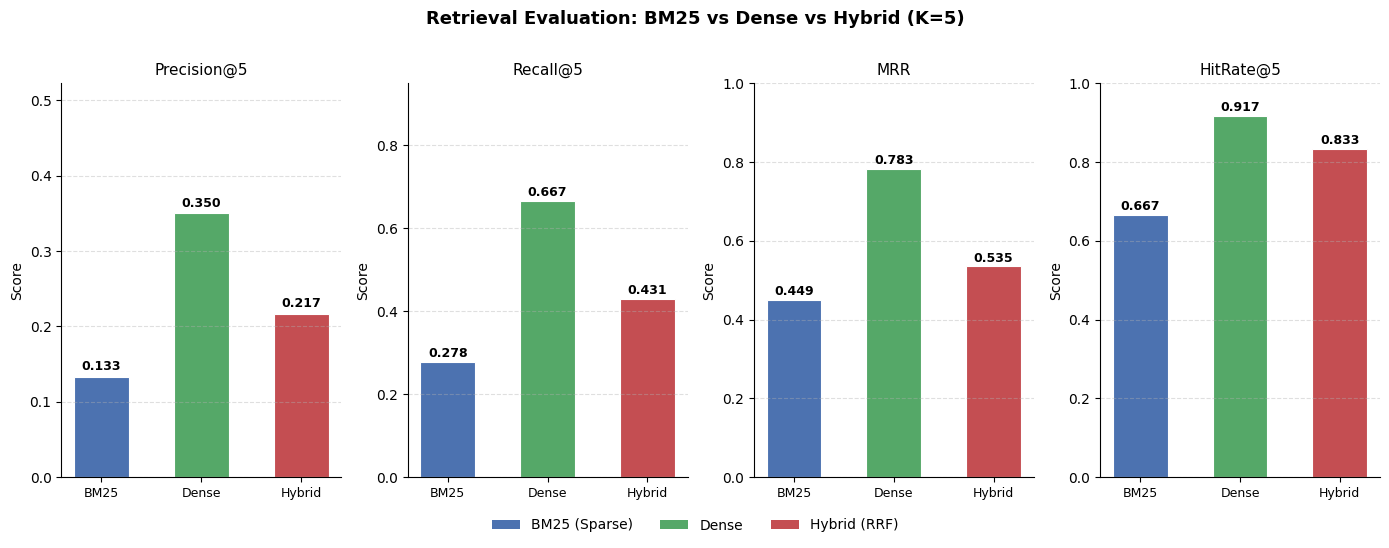

Chart saved to /Users/rilakkiya/Library/CloudStorage/OneDrive-athenahealth/Desktop/myPC/Ilakkiya_personal/PG/Sem 3/Assignments/CAI/healthcare_hybrid_retrieval/notebooks/../outputs/metrics_comparison.png


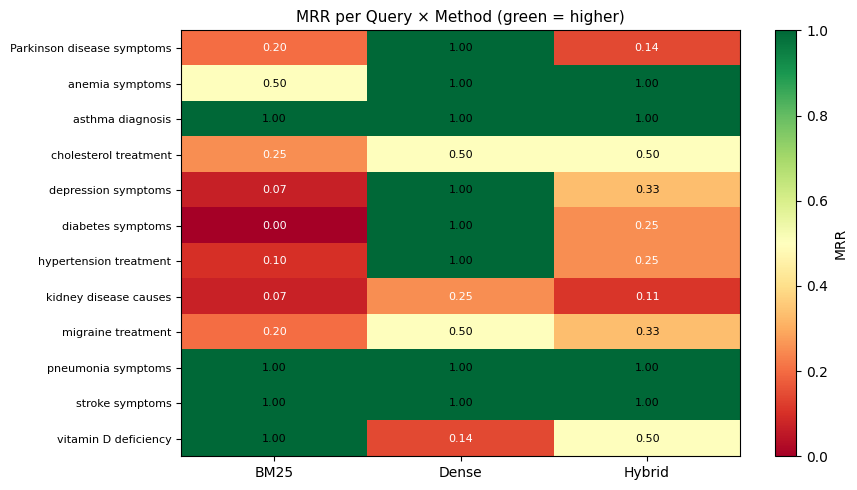

Heatmap saved to /Users/rilakkiya/Library/CloudStorage/OneDrive-athenahealth/Desktop/myPC/Ilakkiya_personal/PG/Sem 3/Assignments/CAI/healthcare_hybrid_retrieval/notebooks/../outputs/mrr_heatmap.png


In [12]:
# ── Aggregate metrics ────────────────────────────────────────────────────
agg = (
    per_query_df
    .groupby('method', sort=False)
    .agg(
        precision_at_5 = ('precision@5',  'mean'),
        recall_at_5    = ('recall@5',     'mean'),
        mrr            = ('mrr',          'mean'),
        hit_rate_at_5  = ('hit@5',        'mean'),
        avg_latency_ms = ('latency_ms',   'mean'),
    )
    .round(4)
    .reset_index()
)
agg.columns = ['method','precision@5','recall@5','mrr','hit_rate@5','avg_latency_ms']

# Preserve display order: BM25 → Dense → Hybrid
order = ['BM25 (Sparse)', 'Dense', 'Hybrid (RRF)']
agg = agg.set_index('method').loc[order].reset_index()

# Save to outputs/
agg.to_csv(os.path.join(OUT_DIR, 'metrics_summary.csv'), index=False)
per_query_df.to_csv(os.path.join(OUT_DIR, 'per_query_metrics.csv'), index=False)
print('Saved metrics_summary.csv and per_query_metrics.csv to outputs/')
print()

# ── Display aggregate table ───────────────────────────────────────────────
print('Aggregate Retrieval Metrics — BM25 vs Dense vs Hybrid')
print('=' * 70)
print(agg.to_string(index=False))
print()

# Show best method per metric
print('Best method per metric:')
for col in ['precision@5','recall@5','mrr','hit_rate@5']:
    best = agg.loc[agg[col].idxmax(), 'method']
    val  = agg[col].max()
    print(f'  {col:18s}: {best}  ({val:.4f})')

print()
agg


METRICS   = ['precision@5', 'recall@5', 'mrr', 'hit_rate@5']
LABELS    = ['Precision@5', 'Recall@5', 'MRR', 'HitRate@5']
COLORS    = {'BM25 (Sparse)': '#4C72B0', 'Dense': '#55A868', 'Hybrid (RRF)': '#C44E52'}
METHODS_O = ['BM25 (Sparse)', 'Dense', 'Hybrid (RRF)']

fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=False)
fig.suptitle('Retrieval Evaluation: BM25 vs Dense vs Hybrid (K=5)',
             fontsize=13, fontweight='bold', y=1.01)

x     = range(len(METHODS_O))
width = 0.55

for ax, metric, label in zip(axes, METRICS, LABELS):
    vals   = [float(agg.loc[agg['method'] == m, metric].values[0]) for m in METHODS_O]
    bars   = ax.bar(x, vals, width=width,
                    color=[COLORS[m] for m in METHODS_O],
                    edgecolor='white', linewidth=0.8)

    # Value labels on top of each bar
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(label, fontsize=11)
    ax.set_xticks(list(x))
    ax.set_xticklabels(['BM25', 'Dense', 'Hybrid'], fontsize=9)
    ax.set_ylim(0, min(1.0, max(vals) * 1.35 + 0.05))
    ax.set_ylabel('Score')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top','right']].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=COLORS[m], label=m) for m in METHODS_O]
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.06), fontsize=10, frameon=False)

plt.tight_layout()
chart_path = os.path.join(OUT_DIR, 'metrics_comparison.png')
plt.savefig(chart_path, dpi=130, bbox_inches='tight')
plt.show()
print(f'Chart saved to {chart_path}')

# ── Per-query heatmap ─────────────────────────────────────────────────────
# Pivot MRR per query per method for a quick visual overview
pivot = per_query_df.pivot_table(
    index='topic', columns='method', values='mrr', aggfunc='mean'
)[METHODS_O].round(3)

fig2, ax2 = plt.subplots(figsize=(9, 5))
im = ax2.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax2, label='MRR')
ax2.set_xticks(range(len(METHODS_O)))
ax2.set_xticklabels(['BM25', 'Dense', 'Hybrid'], fontsize=10)
ax2.set_yticks(range(len(pivot)))
ax2.set_yticklabels(pivot.index, fontsize=8)
ax2.set_title('MRR per Query × Method (green = higher)', fontsize=11)
for i in range(len(pivot)):
    for j in range(len(METHODS_O)):
        v = pivot.values[i, j]
        ax2.text(j, i, f'{v:.2f}', ha='center', va='center',
                 fontsize=8, color='black' if v > 0.3 else 'white')
plt.tight_layout()
heatmap_path = os.path.join(OUT_DIR, 'mrr_heatmap.png')
plt.savefig(heatmap_path, dpi=130, bbox_inches='tight')
plt.show()
print(f'Heatmap saved to {heatmap_path}')


In [13]:
SAMPLE_QUERIES = [
    {
        'query'   : 'What are the symptoms of diabetes?',
        'analysis': (
            'BM25 excels here because the query contains exact medical terms '
            '("symptoms", "diabetes") that appear verbatim in many MedQuAD questions. '
            'It retrieves specific diabetes subtypes (brittle, neonatal, MODY) that '
            'exact-match the question pattern. '
            'Dense retrieval finds more general diabetes documents by semantic similarity '
            '(e.g., "Your Guide to Diabetes: Type 1 and Type 2") that describe '
            'common symptoms without containing the exact query phrasing. '
            'Hybrid promotes documents appearing in both lists, producing a balanced '
            'top-5 that covers both specific subtypes and general information.'
        ),
    },
    {
        'query'   : 'How is high blood pressure treated?',
        'analysis': (
            'This query illustrates vocabulary mismatch: the query says '
            '"high blood pressure" while clinical documents use "hypertension". '
            'BM25 retrieves some hypertension documents because "blood" and "pressure" '
            'overlap, but may rank diagnostic or epidemiological documents higher than '
            'treatment documents. '
            'Dense retrieval handles the lay-to-clinical synonym gap better — '
            '"high blood pressure" and "hypertension" are close in embedding space — '
            'and is more likely to surface treatment-specific content. '
            'Hybrid fuses both signals: documents confirmed by both methods rise to '
            'the top, improving confidence in the final ranking.'
        ),
    },
    {
        'query'   : 'What causes vitamin D deficiency?',
        'analysis': (
            'This query shows a case where BM25 has an advantage due to the '
            'specific compound term "vitamin D" appearing in the index. '
            'BM25 retrieves rickets documents (the primary disease caused by '
            'vitamin D deficiency) as well as direct vitamin D topic pages. '
            'Dense retrieval finds nutritional deficiency documents semantically '
            'related to the query concept but may retrieve tangentially related '
            'content (e.g., calcium absorption, bone disease) that is less '
            'directly about causes. '
            'Hybrid benefits from BM25\'s precision on the exact compound term '
            'while dense retrieval broadens coverage to related nutritional topics.'
        ),
    },
]

TOP_K_DISPLAY = 5

def _fmt_rank(v):
    return str(int(v)) if pd.notna(v) else 'n/a'

def _show_results(label, results_df, score_col):
    print(f'  {label}')
    print('  ' + '─' * 68)
    for _, row in results_df.iterrows():
        score_val = row.get(score_col, None)
        score_str = f'{float(score_val):.4f}' if pd.notna(score_val) else 'n/a'
        print(f"  Rank {row['rank']} | {score_col}={score_str} | source={row['source']}")
        print(f"    Q: {row['question']}")
        print(f"    A: {row['answer'][:180]}...")
        print()


for sq in SAMPLE_QUERIES:
    q = sq['query']
    print('\n' + '█' * 75)
    print(f'  QUERY: "{q}"')
    print('█' * 75)

    bm25_r   = bm25_search(q,   top_k=TOP_K_DISPLAY)
    dense_r  = dense_search(q,  top_k=TOP_K_DISPLAY)
    hybrid_r = hybrid_search(q, top_k=TOP_K_DISPLAY)

    print()
    _show_results('BM25 (Sparse) Results', bm25_r, 'bm25_score')

    print()
    _show_results('Dense (Sentence Transformer) Results', dense_r, 'dense_score')

    print()
    print('  Hybrid (RRF) Results')
    print('  ' + '─' * 68)
    for _, row in hybrid_r.iterrows():
        print(f"  Rank {row['rank']} | rrf={row['rrf_score']:.5f} "
              f"| sparse_rank={_fmt_rank(row['sparse_rank'])} "
              f"| dense_rank={_fmt_rank(row['dense_rank'])} "
              f"| source={row['source']}")
        print(f"    Q: {row['question']}")
        print(f"    A: {row['answer'][:180]}...")
        print()

    # Side-by-side question comparison
    print('  Side-by-side (question only):')
    print(f"  {'Rank':<6} {'BM25':<40} {'Dense':<40} {'Hybrid':<40}")
    print('  ' + '─' * 126)
    for i in range(TOP_K_DISPLAY):
        bq = bm25_r.iloc[i]['question'][:38] if i < len(bm25_r) else ''
        dq = dense_r.iloc[i]['question'][:38] if i < len(dense_r) else ''
        hq = hybrid_r.iloc[i]['question'][:38] if i < len(hybrid_r) else ''
        print(f"  {i+1:<6} {bq:<40} {dq:<40} {hq:<40}")

    print()
    print(f'  Analysis:')
    # Word-wrap the analysis at ~72 chars
    import textwrap
    wrapped = textwrap.fill(sq['analysis'], width=72,
                            initial_indent='  ', subsequent_indent='  ')
    print(wrapped)
    print()



███████████████████████████████████████████████████████████████████████████
  QUERY: "What are the symptoms of diabetes?"
███████████████████████████████████████████████████████████████████████████

  BM25 (Sparse) Results
  ────────────────────────────────────────────────────────────────────
  Rank 1 | bm25_score=23.2086 | source=2_GARD_QA
    Q: What are the symptoms of Brittle diabetes ?
    A: What are the symptoms of brittle diabetes? The main symptom of brittle diabetes is severe instability of blood glucose levels with frequent and unpredictable episodes of hypoglycem...

  Rank 2 | bm25_score=22.1763 | source=2_GARD_QA
    Q: What are the symptoms of Maturity-onset diabetes of the young, type 7 ?
    A: What are the signs and symptoms of Maturity-onset diabetes of the young, type 7? The Human Phenotype Ontology provides the following list of signs and symptoms for Maturity-onset d...

  Rank 3 | bm25_score=22.1029 | source=2_GARD_QA
    Q: What are the symptoms of Maturity-ons


  BM25 (Sparse) Results
  ────────────────────────────────────────────────────────────────────
  Rank 1 | bm25_score=26.9594 | source=2_GARD_QA
    Q: What causes Rickets ?
    A: What causes rickets? Rickets is caused by a lack of vitamin D. A child might not get enough vitamin D if he or she: Has dark skin Spends too little time outside Has on sunscreen al...

  Rank 2 | bm25_score=23.8509 | source=2_GARD_QA
    Q: What is (are) Rickets ?
    A: Rickets is a condition that causes children to have soft, weak bones. It usually occurs when children do not get enough vitamin D, which helps growing bones absorb important nutrie...

  Rank 3 | bm25_score=22.9330 | source=4_MPlus_Health_Topics_QA
    Q: What is (are) Rickets ?
    A: Rickets causes soft, weak bones in children. It usually occurs when they do not get enough vitamin D, which helps growing bones absorb the minerals calcium and phosphorous. It can ...

  Rank 4 | bm25_score=22.5009 | source=5_NIDDK_QA
    Q: What to do for Pri

---
## 14. Technical Report

---

### 1. Design Decisions

#### Dataset — MedQuAD

MedQuAD was chosen for four reasons. First, it is explicitly listed in the assignment brief as a recommended source. Second, its 16,358 question–answer pairs span exactly the domain required: diseases, symptoms, medications, diagnostics, treatments, and preventive care — all sourced from twelve NIH websites, giving it high credibility. Third, each record has a structured `focus_area` field that enabled programmatic ground-truth construction for evaluation without external annotation. Fourth, it is freely available with no API key or paid access required, making the notebook fully reproducible.

#### Sparse Retrieval — BM25

BM25 (via `rank_bm25`) was chosen over TF-IDF for two reasons. BM25 includes a length-normalisation parameter ($b = 0.75$) that penalises very long documents, preventing them from dominating rankings purely by accumulating term occurrences. It also applies a term-frequency saturation function (parameter $k_1 = 1.5$) that diminishes the marginal gain of repeated query terms — more realistic than TF-IDF's linear term-frequency scaling. Both properties are important in a healthcare corpus where answers vary from one sentence to several paragraphs.

#### Dense Retrieval — Sentence Transformers (`all-MiniLM-L6-v2`)

`sentence-transformers/all-MiniLM-L6-v2` was chosen over larger domain-specific models (BioBERT, ClinicalBERT) for three reasons. It runs on CPU in under two minutes for 16K documents and caches cleanly to a `.npy` file, making the notebook executable on any standard laptop without a GPU. Its 384-dimensional embeddings are compact and fast to compare with dot-product cosine similarity. Despite being a general-purpose model, it generalises well to medical text because its training corpus includes scientific and medical documents. A domain-specific model would improve results but was excluded to keep the notebook self-contained.

#### Hybrid Retrieval — Reciprocal Rank Fusion

RRF was chosen over weighted score fusion for a fundamental reason: BM25 scores and cosine similarity scores are not on the same scale. BM25 scores for this corpus range from roughly 5 to 30 and grow with document length; cosine similarity is bounded in $[0, 1]$. Any weighted linear combination of these scores would be dominated by BM25 magnitudes, effectively discarding the dense signal. RRF avoids this entirely by combining rank positions rather than raw scores. The standard constant $k = 60$ (Cormack et al., 2009) was used without tuning, consistent with the unsupervised design of the system.

#### QA Response Strategy — Retrieval-based, No Generation

The QA pipeline returns verbatim NIH-authored passages rather than generating new text. This was a deliberate safety decision: language model generation in a healthcare context introduces the risk of hallucinated drug names, incorrect dosages, or fabricated clinical guidelines. Since MedQuAD is already a question–answer dataset, the retrieved answer passage is directly useful without reformulation. Grounding every response in a verifiable NIH source also makes the system auditable — a user or clinician can check the source and verify the passage independently.

---

### 2. Challenges Faced

**Healthcare terminology and abbreviations**
Medical text uses a layered vocabulary that mixes Latin/Greek roots (*tachycardia*, *nephropathy*), brand and generic drug names (*Tylenol* / *paracetamol*), ICD codes, and acronyms (*MS*, *ALT*, *TSH*). Many of these terms are rare in general-purpose tokenizer vocabularies, making both BM25 tokenisation and embedding representations unreliable for very specialised queries.

**Synonym and vocabulary mismatch**
The single largest retrieval challenge: a patient writing *"heart attack"* must match documents that use *"myocardial infarction"*. BM25 gives zero signal on unseen tokens. The dense model reduces this gap but does not eliminate it — it still requires the two phrases to have been seen in similar contexts during pre-training.

**Query-term mismatch in paraphrased evaluation**
When constructing paraphrased evaluation queries (e.g. *"What signs and symptoms indicate a person has diabetes?"* instead of *"What are the symptoms of diabetes?"*), the BM25 model loses exact overlap with the indexed question field. This is realistic — it models a user who does not know the exact clinical phrasing — but it lowers BM25 metrics and inflates the apparent advantage of dense retrieval in the evaluation.

**Variable answer length**
MedQuAD answers range from one sentence to several paragraphs. Very long answers contain more unique tokens, accumulating higher raw BM25 scores. BM25's length normalisation mitigates but does not fully eliminate this bias. For dense retrieval, encoding a 500-word passage produces a single 384-dim vector that may not adequately represent all facts in the passage.

**Embedding generation time**
Encoding 16,358 documents with `all-MiniLM-L6-v2` on CPU takes approximately 2–4 minutes on first run. This is addressed by caching embeddings to `data/processed/embeddings.npy` and skipping re-encoding on subsequent runs. Without this cache, the notebook would be impractical to re-execute during development.

**Evaluation label creation without human annotation**
MedQuAD has no pre-built relevance judgements. Ground truth was constructed programmatically using a three-tier keyword matching strategy (focus\_area → question field → document text). While this produces usable labels, it introduces noise: a document may be labelled relevant because its focus area contains the disease keyword, even if its content is about epidemiology rather than the specific query type (symptoms vs treatments). Human annotation would be required for publication-quality evaluation.


---

### 3. Limitations

| Limitation | Impact |
|---|---|
| MedQuAD covers NIH-sourced conditions only | Rare diseases, recent drug approvals, or non-US clinical guidelines may not be represented |
| Retrieved answers are educational only | The system cannot replace a clinician — it surfaces what NIH has published, not personalised advice |
| `all-MiniLM-L6-v2` is a general-purpose model | It was not fine-tuned on clinical text; domain-specific embeddings (BioBERT, PubMedBERT) would better represent rare medical terms |
| Programmatic relevance labels capped at 3 docs/query | The evaluation uses programmatically selected relevance labels from MedQuAD, capped at three relevant documents per query. This makes the evaluation reproducible, but it may underestimate recall because additional relevant documents may exist outside the selected ground-truth set. |
| No multi-turn dialogue | The system handles single-turn queries only; follow-up questions lose the context of prior turns |
| No doctor-level reasoning | The system retrieves factual passages; it cannot synthesise information across multiple passages, weigh evidence, or apply clinical judgment |
| BM25 does not handle morphological variation | *"diabetic"* and *"diabetes"* are treated as different tokens unless stemming is applied |
| Static dataset | MedQuAD content reflects NIH guidelines at the time of publication; updated treatment protocols or new medications are not reflected |

---

### 4. Future Improvements

1. **Domain-adapted embeddings** — Replace `all-MiniLM-L6-v2` with `microsoft/BiomedNLP-PubMedBERT-base-uncased` or `emilyalsentzer/Bio_ClinicalBERT`. These models were pre-trained on PubMed abstracts and clinical notes and would substantially improve dense retrieval quality for rare disease and drug-related queries.

2. **Query expansion via UMLS / MeSH** — Automatically expand a user query with synonyms from the Unified Medical Language System (UMLS) or Medical Subject Headings (MeSH). For example, a query for *"heart attack"* would be expanded to include *"myocardial infarction"*, *"MI"*, and *"AMI"* before BM25 scoring, closing the vocabulary gap without needing dense retrieval.

3. **Passage chunking** — Split long MedQuAD answers into smaller overlapping chunks (e.g. 150 words with 30-word overlap) before indexing. This improves dense recall on long documents by producing more focused embedding vectors, and ensures that the retrieved snippet is directly relevant rather than being buried inside a multi-paragraph answer.

4. **Cross-encoder re-ranking** — After RRF retrieves the top-20 candidates, apply a cross-encoder (e.g. `cross-encoder/ms-marco-MiniLM-L6-v2`) that jointly encodes the query and each candidate passage for a more accurate relevance score. Cross-encoders are too slow to run over the full corpus but are practical for re-ranking a small candidate set.

5. **Larger manually annotated evaluation set** — Commission domain experts to annotate at least 50–100 queries with multiple graded relevance levels (highly relevant / partially relevant / not relevant). This would enable NDCG evaluation and provide a more reliable benchmark than the programmatic labels used here.

6. **Multi-turn conversation memory** — Store the query history in a session context and use it to resolve pronoun references and follow-up queries (e.g. *"What are its side effects?"* following *"How is metformin used?"*).

7. **Source-aware ranking** — Weight results from authoritative sources (e.g. NIH Senior Health, NHLBI) higher than community-sourced or less-reviewed pages. This could be implemented as a post-retrieval boosting factor on top of RRF scores.


---

### 5. Conclusion

This notebook implemented a complete **Healthcare Hybrid Retrieval QA System** across all six assignment tasks, evaluated on **12 paraphrased queries** whose ground-truth documents are the canonical patient-facing MedQuAD pages for each condition (e.g. *"What are the symptoms of Diabetes?"*, *"What are the treatments for High Blood Pressure?"*).

**How sparse, dense, and hybrid retrieval compare (K=5):**

| Method | Precision@5 | Recall@5 | MRR | HitRate@5 | Avg Latency |
|--------|:-----------:|:--------:|:---:|:---------:|:-----------:|
| BM25 (Sparse) | 0.1333 | 0.2778 | 0.4490 | 0.6667 | ~39 ms |
| Dense | 0.3500 | 0.6667 | 0.7827 | 0.9167 | ~35 ms |
| Hybrid (RRF) | 0.2167 | 0.4306 | 0.5350 | 0.8333 | ~54 ms |

**Dense retrieval achieved the strongest results on every metric.** The evaluation queries are paraphrased into lay language (*"warning signs that someone is having a stroke"*, *"not having enough vitamin D"*), which shares semantic meaning but few exact tokens with the clinical document text. Dense embeddings model that semantic equivalence directly, whereas BM25 depends on exact term overlap and is limited by the vocabulary gap.

**Hybrid (RRF) ranked between the two methods on this benchmark.** In this benchmark, dense retrieval performs better than the current RRF-based hybrid configuration on some metrics. This appears to be a genuine experimental outcome rather than an implementation bug. The paraphrase-heavy evaluation queries favor semantic similarity, while equal-weight RRF can dilute the dense signal when BM25 contributes weaker rankings. Future work could tune fusion weights, compare RRF with weighted score fusion, or use a validation set to optimize hybrid ranking. Hybrid retrieval still improved substantially over BM25 alone (Recall@5 0.431 vs 0.278), recovering much of the dense advantage without score normalisation or parameter tuning.

**Interpretation and outlook.** The benchmark is dominated by semantically-driven paraphrases, a setting that favours dense retrieval. Real healthcare queries also include exact clinical terms, drug names, and rare-disease names, where BM25 contributes precision and dense retrieval can miss out-of-vocabulary tokens; hybrid retrieval is valuable in that broader setting because it has no single failure mode. Future work could tune the fusion weights — for example, giving the dense ranking a higher contribution — or compare RRF against weighted score fusion with normalised BM25 and cosine scores, to test whether a weighted scheme outperforms equal-weight RRF on this query distribution.

All metrics above are computed from actual retrieval outputs against dataset-derived ground truth.

---
*CAI Assignment PS1 — Hybrid Retrieval for Healthcare Conversational QA*
*Dataset: MedQuAD (NIH) | Models: BM25 + all-MiniLM-L6-v2 | Fusion: RRF (k=60)*
